# Generator–Evaluator Pattern with LangGraph

This graph generates a random integer between 1 and 10, evaluates it against a target (`target_count`), and retries until it succeeds or reaches `max_attempts`.

In [17]:
import random
from typing import Literal, TypedDict

from langgraph.graph import END, START, StateGraph

## Define the state and nodes

The generator updates the attempt counter and output history. The evaluator records whether the graph should succeed, retry, or stop because it has used every attempt.

In [18]:
class GeneratorEvaluatorState(TypedDict):
    target_count: int
    max_attempts: int
    current_attempt: int
    generated_outputs: list[int]
    result: str


def generate_number(state: GeneratorEvaluatorState) -> dict:
    generated_number = random.randint(1, 10)
    return {
        "current_attempt": state["current_attempt"] + 1,
        "generated_outputs": [*state["generated_outputs"], generated_number],
    }


def evaluate_number(state: GeneratorEvaluatorState) -> dict:
    latest_output = state["generated_outputs"][-1]

    if latest_output == state["target_count"]:
        result = "success"
    elif state["current_attempt"] < state["max_attempts"]:
        result = "retry"
    else:
        result = "max_attempts_reached"

    return {"result": result}


def route_after_evaluation(
    state: GeneratorEvaluatorState,
) -> Literal["end", "retry"]:

    if state["result"] == "retry":
        return "retry"

    return "end"

## Build and compile the graph

In [19]:
builder = StateGraph(GeneratorEvaluatorState)
builder.add_node("generator", generate_number)
builder.add_node("evaluator", evaluate_number)

builder.add_edge(START, "generator")
builder.add_edge("generator", "evaluator")
builder.add_conditional_edges(
    "evaluator",
    route_after_evaluation,
    {
        "retry": "generator",
        "end": END,
    },
)

graph = builder.compile()

## Inspect the graph

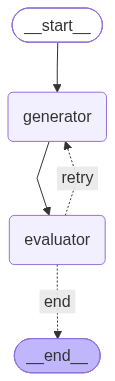

In [20]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

## Run an example

The random number generator is intentionally unseeded, so the path and result can differ each time this cell runs.

In [26]:
initial_state: GeneratorEvaluatorState = {
    "target_count": 7,
    "max_attempts": 5,
    "current_attempt": 0,
    "generated_outputs": [],
    "result": "",
}

if not 1 <= initial_state["target_count"] <= 10:
    raise ValueError("target_count must be between 1 and 10.")
if initial_state["max_attempts"] < 1:
    raise ValueError("max_attempts must be at least 1.")

final_state = graph.invoke(initial_state)

print(f"Target count: {final_state['target_count']}")
print(f"Attempts: {final_state['current_attempt']}")
print(f"Generated outputs: {final_state['generated_outputs']}")

if final_state["result"] == "success":
    attempt = final_state["current_attempt"]
    suffix = (
        "th"
        if 10 <= attempt % 100 <= 20
        else {1: "st", 2: "nd", 3: "rd"}.get(attempt % 10, "th")
    )
    print(f"Success: generated the target count in {attempt}{suffix} attempt")
else:
    print("No match: max_attempts was reached.")

Target count: 7
Attempts: 2
Generated outputs: [6, 7]
Success: generated the target count in 2nd attempt
